<a href="https://colab.research.google.com/github/Priya-Saini-1/DataScience_Grras/blob/Python/Day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# handle missing values
import pandas as pd
import numpy as np
data = {
    "colors":['red','green','blue','orange','green','blue',np.nan]
}
df = pd.DataFrame(data)
# print(df)

# handle null values
df.dropna(inplace=True)
print(df)

   colors
0     red
1   green
2    blue
3  orange
4   green
5    blue


In [19]:

# label encoding
from sklearn.preprocessing import LabelEncoder

# method 1
le = LabelEncoder()
df['colors_encoder1'] = le.fit_transform(df['colors'])

# method 2
df['colors_encoder2'] = LabelEncoder().fit_transform(df['colors'])
# print(df)

# method 3
import sklearn
df['colors_encoder3'] = sklearn.preprocessing.LabelEncoder().fit_transform(df['colors'])
print(df)


   colors  colors_encoder1  colors_encoder2  colors_encoder3
0     red                3                3                3
1   green                1                1                1
2    blue                0                0                0
3  orange                2                2                2
4   green                1                1                1
5    blue                0                0                0


In [20]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
print(df)

# drop cols of label encoding
if 'colors_encoder' in df.keys():
  df.drop(df[['colors_encoder','colors_encoder1','colors_encoder2','colors_encoder3']],axis=1,inplace=True)

print(df)

# one hot encoding (by the help of sklearn)
encoder = OneHotEncoder()
encoded = encoder.fit_transform(df[['colors']])
print(encoded.toarray())

# one hot encoding (by the help of pandas)
df_encoder = pd.get_dummies(df,columns=['colors'])
print(df_encoder)



   colors  colors_encoder1  colors_encoder2  colors_encoder3
0     red                3                3                3
1   green                1                1                1
2    blue                0                0                0
3  orange                2                2                2
4   green                1                1                1
5    blue                0                0                0
   colors  colors_encoder1  colors_encoder2  colors_encoder3
0     red                3                3                3
1   green                1                1                1
2    blue                0                0                0
3  orange                2                2                2
4   green                1                1                1
5    blue                0                0                0
[[0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]
   colors_encoder1  colors_encoder2  colors_encoder3  c

In [21]:

# combination of handle missing value | label encoding | onehot encoding
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

data = {
    "age":[10,20,np.nan,26,30],
    "gender":['male','female','others','male',np.nan],
    "name":['dheeraj','kavi','sapu','yash','hello']
}

df = pd.DataFrame(data)

# handle missing values
df['age'] = df['age'].fillna(df['age'].mean())
df.dropna(subset=['gender'],inplace=True)
print(df)

# label encoding
le = LabelEncoder()
df['gender1'] = le.fit_transform(df['gender'])
print(df)

# one hot encoding
oe = OneHotEncoder()
oe_e = oe.fit_transform(df[['gender']]).toarray()
print(oe_e)

    age  gender     name
0  10.0    male  dheeraj
1  20.0  female     kavi
2  21.5  others     sapu
3  26.0    male     yash
    age  gender     name  gender1
0  10.0    male  dheeraj        1
1  20.0  female     kavi        0
2  21.5  others     sapu        2
3  26.0    male     yash        1
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


   experirence  salary
0          300   10000
1          600   20000
2          900   30000
3         1500   40000
   experirence    salary  experience
0          300 -1.341641   -1.183216
1          600 -0.447214   -0.507093
2          900  0.447214    0.169031
3         1500  1.341641    1.521278
0   -1.183216
1   -0.507093
2    0.169031
3    1.521278
Name: experience, dtype: float64
0   -1.341641
1   -0.447214
2    0.447214
3    1.341641
Name: salary, dtype: float64


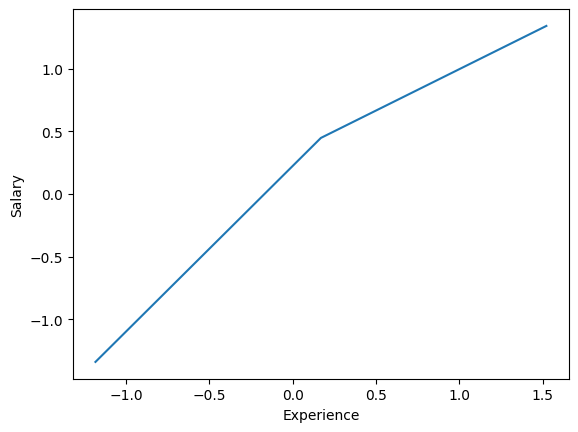

In [22]:
# feature scaling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = {
    "experirence" : [300, 600, 900, 1500],
    "salary" : [10000, 20000, 30000, 40000]
}

df = pd.DataFrame(data)
print(df)

scaler = StandardScaler()
df["experience"] = scaler.fit_transform(df[["experirence"]])
df["salary"] = scaler.fit_transform(df[["salary"]])
print(df)

# split data
X = df['experience'] # capital X
y = df['salary']

print(X)
print(y)

plt.plot(X,y)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

In [23]:
# data split training testing
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = {
    "experience":[300,600,900,1500],
    "salary":[1000,1500,2000,3000]
}

df = pd.DataFrame(data)
print(df)

# split data
X = df['experience'] # capital X
y = df['salary']

# train test split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
print("x train: ",x_train)
print("x test: ",x_test)
print("y train: ", y_train)
print("y test: ", y_test)




   experience  salary
0         300    1000
1         600    1500
2         900    2000
3        1500    3000
x train:  1     600
2     900
3    1500
Name: experience, dtype: int64
x test:  0    300
Name: experience, dtype: int64
y train:  1    1500
2    2000
3    3000
Name: salary, dtype: int64
y test:  0    1000
Name: salary, dtype: int64


In [24]:
# data split training testing
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = "https://raw.githubusercontent.com/rajendra0968jangid/Ds-Arya/main/extended_salary_data.csv"

df = pd.read_csv(data)
# print(df)

# split data
X = df['experience'] # capital X
y = df['salary']

# train test split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("x train: ",x_train )
print("x test: ",x_test)
print("y train: ", y_train)
print("y test: ", y_test)



x train:  55     17100
22      7200
76     23400
44     13800
72     22200
       ...  
71     21900
14      4800
92     28200
51     15900
102    31200
Name: experience, Length: 83, dtype: int64
x test:  30     9600
65    20100
64    19800
53    16500
45    14100
93    28500
91    27900
47    14700
10     3600
0       300
18     6000
31     9900
88    27000
95    29100
77    23700
4      1800
80    24600
33    10500
12     4200
26     8400
98    30000
Name: experience, dtype: int64
y train:  55     29000
22     12500
76     39500
44     23500
72     37500
       ...  
71     37000
14      8500
92     47500
51     27000
102    52500
Name: salary, Length: 83, dtype: int64
y test:  30    16500
65    34000
64    33500
53    28000
45    24000
93    48000
91    47000
47    25000
10     6500
0      1000
18    10500
31    17000
88    45500
95    49000
77    40000
4      3500
80    41500
33    18000
12     7500
26    14500
98    50500
Name: salary, dtype: int64


In [28]:
from sklearn.linear_model import LinearRegression

# model fit
model = LinearRegression()
# The X and y arrays for fit should be 2D, typically (n_samples, n_features).
# Converting the Series x_train and y_train to DataFrames ensures they are shaped as (n_samples, 1).
model.fit(x_train.to_frame(), y_train.to_frame())

# input from user
user = int(input("Enter your Experience: "))
# model prediction

new_data = {
    "experience":[user]
}

df1 = pd.DataFrame(new_data)
print(df1)
pred_data = model.predict(df1)
print(pred_data[0])

Enter your Experience: 23
   experience
0          23
[538.33333333]
